# Modelo XGBoost
---

### Configuración de ambiente

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb

# Carga de modulos_apex
from modulos_apex_dev import BTC_DataExtractor as btc_etl
from modulos_apex_dev import trading_backtester as tbt

import os
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

CURRENT_DIR = os.getcwd()

## Carga de datos
---


In [2]:
CURRENT_DIR

'/Users/julesaccm/Documents/Repos/Apex-project/notebooks'

In [3]:
# Cargamos los datos desde la carpeta data y si no existen, ejecutamos el pipeline
try: 
    os.chdir('..')
    os.chdir('data/processed')
    df_final = pd.read_csv('btc_data.csv', index_col=0)
    print("Datos cargados desde 'data/processed/btc_data.csv'")

except FileNotFoundError:
    print("Archivo no encontrado. Ejecutando el pipeline para generar los datos...")

    # 1. Instanciar la clase (Configuramos las variables globales del proceso)
    extractor = btc_etl.BTC_DataExtractor(
        fecha_inicio="2024-01-01", 
        fecha_fin="2026-01-01", 
        ventana_critica=5
    )

    # 2. Ejecutar las transformaciones en cadena (Pipeline)
    # Cada paso toma el DataFrame del paso anterior, lo transforma y lo devuelve

    # Paso A: Obtener el precio histórico y volumen
    df_base = extractor.obtener_datos_btc()

    # Paso B: Etiquetar máximos y mínimos (Nuestro Target)
    df_etiquetado = extractor.etiquetar_puntos_criticos(df_base)

    # Paso C: Calcular todo el análisis técnico
    df_con_indicadores = extractor.agregar_indicadores_avanzados(df_etiquetado)

    # Paso D: Enriquecer con datos macroeconómicos
    df_final = extractor.agregar_contexto_macro(df_con_indicadores)

    # 3. Revisar el resultado final
    print("\n--- Vista previa de las primeras 5 filas ---")
    print(df_final.head())

    # Creamos el archivo en la carpeta data/processed
    os.chdir(CURRENT_DIR)
    os.chdir('..')
    os.makedirs('data/processed', exist_ok=True)
    df_final.to_csv('data/processed/btc_data.csv', index=True)
    
    print("Datos generados y guardados en 'data/processed/btc_data.csv'")

finally:
    os.chdir(CURRENT_DIR) 


Datos cargados desde 'data/processed/btc_data.csv'


In [4]:
df_final.head()

,Open,High,Low,Close,Volume,Retorno_Log,Target,RSI_14,BBL_20_2.0_2.0,BBM_20_2.0_2.0,...,ROC_10,BULLP_13,BEARP_13,UO_7_14_28,SP500_Close,DXY_Close,Oro_Close,SP500_Retorno,DXY_Retorno,Oro_Retorno
Date,,,,,,,,,,,,,,,,,,,,,
2024-02-04,42994.941406,43097.644531,42374.832031,42583.582031,14802225490,-0.009551,0,55.156994,39455.992843,41899.333984,...,6.635414,619.166722,-103.645778,54.454136,4942.810059,104.449997,2025.699951,0.000000,0.000000,0.000000
2024-02-05,42577.621094,43494.250000,42264.816406,42658.667969,18715487317,0.001762,0,55.579270,39475.186244,41874.520117,...,2.013056,990.030739,-239.402854,47.903907,4942.810059,104.449997,2025.699951,0.000000,0.000000,0.000000
2024-02-06,42657.390625,43344.148438,42529.019531,43084.671875,16798476726,0.009937,0,57.996020,39461.555932,41891.621094,...,2.290161,757.007375,-58.121531,51.256441,4954.229980,104.180000,2034.500000,0.002310,-0.002585,0.004344
2024-02-07,43090.019531,44341.949219,42775.957031,44318.222656,21126587775,0.028229,0,64.088663,39405.656914,42044.429297,...,5.430229,1507.510786,-58.481402,62.110142,4995.060059,104.040001,2035.199951,0.008241,-0.001344,0.000344
2024-02-08,44332.125000,45575.839844,44332.125000,45301.566406,26154524080,0.021946,0,68.065262,39225.992581,42228.587305,...,4.650963,2388.954557,1145.239714,61.831010,4997.910156,104.150002,2032.199951,0.000571,0.001057,-0.001474


## Configuración para el modelo XGBoost
---

In [5]:
# --- 1. CONFIGURACIÓN DE FEATURES ---
df_apex = df_final.copy()

# Excluimos los precios crudos de BTC, el Target y los precios crudos macroeconómicos
columnas_excluir = [
    'Open', 'High', 'Low', 'Close', 'Volume', 'Target',
    'SP500_Close', 'DXY_Close', 'Oro_Close' # ¡Importante! Solo queremos sus retornos
    , 'Retorno_Log'
]

# Creamos la lista final de features (X)
features = [col for col in df_apex.columns if col not in columnas_excluir]

# --- 2. PREPARACIÓN DE DATOS (Train / Test) ---
X = df_apex[features]
y = df_apex['Target']

# División cronológica (80% Train, 20% Test)
split_idx = int(len(df_apex) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Entrenando con {len(features)} variables (Técnicas + Macro)...")
print(f"Días de entrenamiento: {len(X_train)} | Días de prueba: {len(X_test)}")

# Traducir las etiquetas (-1, 0, 1) a formato XGBoost (0, 1, 2)
le = LabelEncoder()
y_train_xgb = le.fit_transform(y_train)
y_test_xgb = le.transform(y_test)

Entrenando con 30 variables (Técnicas + Macro)...
Días de entrenamiento: 557 | Días de prueba: 140


In [6]:
# 5. Recuperamos la porción de "Test" pero del DataFrame original (que SÍ tiene 'Close')
split_idx = int(len(df_apex) * 0.8)
df_test_completo = df_apex.iloc[split_idx:].copy()


## Optimización bayesiana
---

## Optimización del modelo

In [ ]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
import xgboost as xgb
import numpy as np

print("--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL MODELO ---")

# 1. Definimos el espacio de búsqueda Bayesiano para XGBoost
space_modelo = {
    'max_depth': hp.quniform('max_depth', 3, 8, 1),
    'learning_rate': hp.loguniform('learning_rate', -6, -2), # np.exp(-6) a np.exp(-2)
    'subsample': hp.uniform('subsample', 0.6, 1.0),
    'gamma': hp.uniform('gamma', 0, 0.5),
    'n_estimators': hp.quniform('n_estimators', 50, 300, 50),
    'scale_pos_weight': hp.uniform('scale_pos_weight', 1, 10),
    'umbral': hp.quniform('umbral', 0.20, 0.35, 0.05) # 0.20, 0.25, 0.30, 0.35
}

# 2. Función Objetivo que Hyperopt intentará "Minimizar"
def objective_model(params):
    # Hyperopt con quniform devuelve floats, XGBoost exige enteros en estos campos
    max_depth = int(params['max_depth'])
    n_estimators = int(params['n_estimators'])
    umbral = params['umbral']
    
    modelo_tuning = xgb.XGBClassifier(
        max_depth=max_depth,
        learning_rate=params['learning_rate'],
        subsample=params['subsample'],
        gamma=params['gamma'],
        n_estimators=n_estimators,
        scale_pos_weight=params['scale_pos_weight'],
        early_stopping_rounds=50, # Tu recomendación aplicada
        random_state=42,
        n_jobs=-1
    )
    
    # Entrenamos pasándole el conjunto de prueba para el Early Stopping
    modelo_tuning.fit(
        X_train, y_train_xgb,
        eval_set=[(X_test, y_test_xgb)],
        verbose=False
    )
    
    # Predecimos probabilidades
    probabilidades = modelo_tuning.predict_proba(X_test)
    y_pred_tuning = np.zeros(len(y_test))
    
    # Encontramos qué columna de probabilidad corresponde al Mínimo y al Máximo
    idx_minimo = np.where(le.classes_ == -1)[0][0]
    idx_maximo = np.where(le.classes_ == 1)[0][0]

    # Aplicamos el umbral Bayesiano
    for j in range(len(probabilidades)):
        if probabilidades[j][idx_minimo] >= umbral:
            y_pred_tuning[j] = -1
        elif probabilidades[j][idx_maximo] >= umbral:
            y_pred_tuning[j] = 1
            
    # Instanciamos el Backtester con parámetros de riesgo fijos (por ahora)
    bt_temp = tbt.Backtester(df_test_completo, capital_inicial=1000.0)
    retorno, _ = bt_temp.backtest_con_trailing_stop(
        predicciones=y_pred_tuning,
        tamaño_posicion=0.30, 
        stop_loss_inicial=0.03, 
        trailing_activation=0.03, 
        trailing_distancia=0.015
    )
    
    # E. Guardamos el campeón
    if retorno > mejor_retorno:
        mejor_retorno = retorno
        mejor_historial = _

    # Hyperopt minimiza, por lo que devolvemos el retorno negativo
    # Si ganamos 5%, devuelve -5 (que es "menor" y por tanto, "mejor" para Hyperopt)
    return {'loss': -retorno, 'status': STATUS_OK}

# 3. Ejecutamos la búsqueda (max_evals controla cuántas iteraciones hará)
trials_modelo = Trials()
mejores_parametros_modelo = fmin(
    fn=objective_model,
    space=space_modelo,
    algo=tpe.suggest,      # El algoritmo mágico: Tree-structured Parzen Estimator
    max_evals=50,          # Puedes subir esto a 100 o 200 si tienes tiempo
    trials=trials_modelo,
    rstate=np.random.default_rng(42)
)

print("\nMEJORES PARÁMETROS BAYESIANOS (MODELO):")
print(mejores_parametros_modelo)

--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL MODELO ---
--- RESULTADOS DEL BACKTEST ---                       
Capital Inicial: $1000.00 USD                         
Capital Final: $1051.08 USD                           
Retorno Total: 5.11%                                  
Total de operaciones cerradas: 8                      
--- RESULTADOS DEL BACKTEST ---                                                 
Capital Inicial: $1000.00 USD                                                   
Capital Final: $1004.24 USD                                                     
Retorno Total: 0.42%                                                            
Total de operaciones cerradas: 16                                               
--- RESULTADOS DEL BACKTEST ---                                                 
Capital Inicial: $1000.00 USD                                                   
Capital Final: $995.91 USD                                                      
Retorno Total: -0.41%    

## Optimización de la gestión del riesgo

In [8]:
print("\n--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL ESCUDO ---")

# --- ¡IMPORTANTE! --- 
# Aquí debes reemplazar estos valores con los que te arroje el bloque 1
# (Hyperopt te devuelve los valores en un diccionario)
# --------------------
campeon_max_depth = int(mejores_parametros_modelo['max_depth'])
campeon_n_estimators = int(mejores_parametros_modelo['n_estimators'])
campeon_umbral = mejores_parametros_modelo['umbral']

# 1. Entrenamos al campeón definitivo
modelo_definitivo = xgb.XGBClassifier(
    max_depth=campeon_max_depth,
    learning_rate=mejores_parametros_modelo['learning_rate'],
    subsample=mejores_parametros_modelo['subsample'],
    gamma=mejores_parametros_modelo['gamma'],
    n_estimators=campeon_n_estimators,
    scale_pos_weight=mejores_parametros_modelo['scale_pos_weight'],
    random_state=42,
    n_jobs=-1
)

modelo_definitivo.fit(X_train, y_train_xgb)
probabilidades_definitivas = modelo_definitivo.predict_proba(X_test)

y_pred_fijo = np.zeros(len(y_test))

# Encontramos qué columna de probabilidad corresponde al Mínimo y al Máximo
idx_minimo = np.where(le.classes_ == -1)[0][0]
idx_maximo = np.where(le.classes_ == 1)[0][0]

for j in range(len(probabilidades_definitivas)):
    if probabilidades_definitivas[j][idx_minimo] >= campeon_umbral:
        y_pred_fijo[j] = -1
    elif probabilidades_definitivas[j][idx_maximo] >= campeon_umbral:
        y_pred_fijo[j] = 1

# 2. Definimos el espacio de búsqueda Bayesiano para el Escudo (Tus rangos exactos)
space_riesgo = {
    'tamaño_posicion': hp.quniform('tamaño_posicion', 0.10, 0.35, 0.05),
    'stop_loss_inicial': hp.quniform('stop_loss_inicial', 0.03, 0.10, 0.01),
    'trailing_activation': hp.quniform('trailing_activation', 0.03, 0.10, 0.01),
    'trailing_distancia': hp.quniform('trailing_distancia', 0.015, 0.05, 0.005)
}

# 3. Función Objetivo del Escudo
def objective_shield(params):
    # Filtro lógico de protección
    if params['trailing_distancia'] >= params['trailing_activation']:
        return {'loss': 0, 'status': STATUS_OK} # Penalizamos combinaciones imposibles
        
    bt_definitivo = tbt.Backtester(df_test_completo, capital_inicial=1000.0)
    retorno, _ = bt_definitivo.backtest_con_trailing_stop(
        predicciones=y_pred_fijo,
        tamaño_posicion=params['tamaño_posicion'],
        stop_loss_inicial=params['stop_loss_inicial'],
        trailing_activation=params['trailing_activation'],
        trailing_distancia=params['trailing_distancia'],
        graficar=False
    )
    return {'loss': -retorno, 'status': STATUS_OK}

# 4. Ejecutamos la búsqueda del Escudo
trials_riesgo = Trials()
mejores_parametros_riesgo = fmin(
    fn=objective_shield,
    space=space_riesgo,
    algo=tpe.suggest,
    max_evals=100, # Al ser un cálculo rápido sin entrenar modelo, podemos hacer 100 pruebas
    trials=trials_riesgo,
    rstate=np.random.default_rng(42)
)

print("\nMEJORES PARÁMETROS BAYESIANOS (ESCUDO):")
print(mejores_parametros_riesgo)


--- INICIANDO OPTIMIZACIÓN BAYESIANA DEL ESCUDO ---
--- RESULTADOS DEL BACKTEST ---                        
Capital Inicial: $1000.00 USD                          
Capital Final: $972.46 USD                             
Retorno Total: -2.75%                                  
Total de operaciones cerradas: 5                       
--- RESULTADOS DEL BACKTEST ---                                                 
Capital Inicial: $1000.00 USD                                                   
Capital Final: $1017.37 USD                                                     
Retorno Total: 1.74%                                                            
Total de operaciones cerradas: 7                                                
--- RESULTADOS DEL BACKTEST ---                                                 
Capital Inicial: $1000.00 USD                                                     
Capital Final: $1012.78 USD                                                       
Retorno Total: 

## Mejores parámetros
---

In [11]:
pd.DataFrame([mejores_parametros_modelo])

,gamma,learning_rate,max_depth,n_estimators,scale_pos_weight,subsample,umbral
0,0.117266,0.004573,4.0,300.0,4.15615,0.641233,0.25


In [12]:
pd.DataFrame([mejores_parametros_riesgo])

,stop_loss_inicial,tamaño_posicion,trailing_activation,trailing_distancia
0,0.03,0.35,0.03,0.015


--- RESULTADOS DEL BACKTEST ---
Capital Inicial: $1000.00 USD
Capital Final: $1075.50 USD
Retorno Total: 7.55%
Total de operaciones cerradas: 9


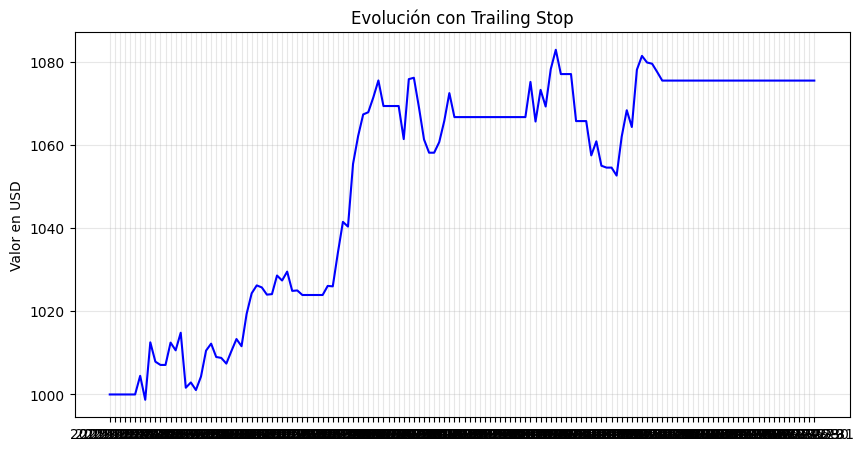

(np.float64(7.5499982933481995),
          Fecha                   Tipo         Precio      Capital
 0   2025-08-19                 Compra  112831.179688  1000.000000
 1   2025-08-24  Venta (Trailing Stop)  115120.974648  1007.102897
 2   2025-08-25                 Compra  110124.351562  1007.102897
 3   2025-09-21  Venta (Trailing Stop)  115380.145078  1023.925640
 4   2025-09-25                 Compra  109049.289062  1023.925640
 5   2025-10-07  Venta (Trailing Stop)  122881.243281  1069.382263
 6   2025-10-10                 Compra  113214.367188  1069.382263
 7   2025-10-16   Venta (Stop Inicial)  109817.936172  1058.153749
 8   2025-10-17                 Compra  106467.789062  1058.153749
 9   2025-10-21  Venta (Trailing Stop)  108930.095742  1066.719013
 10  2025-11-04                 Compra  101590.523438  1066.719013
 11  2025-11-11  Venta (Trailing Stop)  104406.644844  1077.068439
 12  2025-11-13                 Compra   99697.492188  1077.068439
 13  2025-11-14   Venta (Stop

In [13]:
tbt.Backtester(df_test_completo, capital_inicial=1000.0).backtest_con_trailing_stop(
        predicciones=y_pred_fijo,
        tamaño_posicion=mejores_parametros_riesgo['tamaño_posicion'],
        stop_loss_inicial=mejores_parametros_riesgo['stop_loss_inicial'],
        trailing_activation=mejores_parametros_riesgo['trailing_activation'],
        trailing_distancia=mejores_parametros_riesgo['trailing_distancia'],
        graficar=True
    )

In [15]:
X_test.index.values.min(), X_test.index.values.max()

('2025-08-14', '2025-12-31')

## Out-of-time validation
---

### Carga de datos OOT

In [26]:
# Cargamos los datos desde la carpeta data y si no existen, ejecutamos el pipeline
try: 
    os.chdir('..')
    os.chdir('data/processed')
    df_oot = pd.read_csv('btc_data_oot.csv', index_col=0)
    print("Datos cargados desde 'data/processed/btc_data_oot.csv'")

except FileNotFoundError:
    print("Archivo no encontrado. Ejecutando el pipeline para generar los datos...")

    # 1. Instanciar la clase (Configuramos las variables globales del proceso)
    extractor = btc_etl.BTC_DataExtractor(
        fecha_inicio="2026-01-02", 
        fecha_fin="2026-03-26", 
        ventana_critica=5
    )

    # 2. Ejecutar las transformaciones en cadena (Pipeline)
    # Cada paso toma el DataFrame del paso anterior, lo transforma y lo devuelve

    # Paso A: Obtener el precio histórico y volumen
    df_base = extractor.obtener_datos_btc()

    # Paso B: Etiquetar máximos y mínimos (Nuestro Target)
    df_etiquetado = extractor.etiquetar_puntos_criticos(df_base)

    # Paso C: Calcular todo el análisis técnico
    df_con_indicadores = extractor.agregar_indicadores_avanzados(df_etiquetado)

    # Paso D: Enriquecer con datos macroeconómicos
    df_oot = extractor.agregar_contexto_macro(df_con_indicadores)

    # 3. Revisar el resultado final
    print("\n--- Vista previa de las primeras 5 filas ---")
    print(df_oot.head())

    # Creamos el archivo en la carpeta data/processed
    os.chdir(CURRENT_DIR)
    os.chdir('..')
    os.makedirs('data/processed', exist_ok=True)
    df_oot.to_csv('data/processed/btc_data_oot.csv', index=True)
    
    print("Datos generados y guardados en 'data/processed/btc_data_oot.csv'")

finally:
    os.chdir(CURRENT_DIR) 


[*********************100%***********************]  1 of 1 completed

Archivo no encontrado. Ejecutando el pipeline para generar los datos...
Descargando datos de BTC-USD desde 2026-01-02...
Iniciando descarga de datos macroeconómicos...
-> Descargando SP500 (^GSPC)...


-> Descargando DXY (DX-Y.NYB)...
-> Descargando Oro (GC=F)...

¡Contexto macro agregado exitosamente!

--- Vista previa de las primeras 5 filas ---
                    Open          High           Low         Close  \
Date                                                                 
2026-02-05  73016.375000  73161.554688  62353.535156  62702.097656   
2026-02-06  62704.453125  71681.304688  60074.203125  70555.390625   
2026-02-07  70553.796875  71611.148438  67364.445312  69281.968750   
2026-02-08  69283.726562  72206.906250  68852.898438  70264.726562   
2026-02-09  70243.328125  71369.968750  68291.031250  70120.781250   

                  Volume  Retorno_Log  Target     RSI_14  BBL_20_2.0_2.0  \
Date                                                                       
2026-02-05  125509410908    -0.152334       0  16.323595    68560.834101   
2026-02-06  114674259489     0.118003      -1  33.434033    66928.179370   
2026-02-07   62347107663    -0.018213       0  32.281337 

In [27]:
df_oot.index.values.min(), df_oot.index.values.max()

(np.datetime64('2026-02-05T00:00:00.000000000'),
 np.datetime64('2026-03-25T00:00:00.000000000'))

3. Generando predicciones con el modelo campeón...
   -> Señales generadas: 8 alertas detectadas.
4. Ejecutando Backtester con Gestión de Riesgo Óptima...
--- RESULTADOS DEL BACKTEST ---
Capital Inicial: $1000.00 USD
Capital Final: $1032.18 USD
Retorno Total: 3.22%
Total de operaciones cerradas: 3


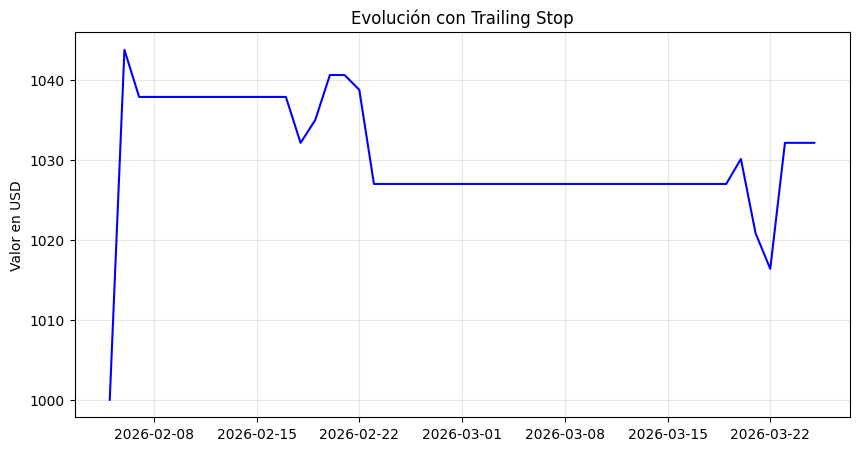


Historial de Operaciones en el OOT:
       Fecha                   Tipo        Precio      Capital
0 2026-02-05                 Compra  62702.097656  1000.000000
1 2026-02-07  Venta (Trailing Stop)  69497.059766  1037.929142
2 2026-02-17                 Compra  67494.218750  1037.929142
3 2026-02-23   Venta (Stop Inicial)  65469.392188  1027.030886
4 2026-03-19                 Compra  69912.789062  1027.030886
5 2026-03-23   Venta (Señal Modelo)  70914.859375  1032.183090


In [28]:
X_oot = df_oot[features]

# --- 3. PREDICCIÓN A CIEGAS ---
print("3. Generando predicciones con el modelo campeón...")
# Usamos modelo_definitivo (que ya tiene los hiperparámetros bayesianos)
probabilidades_oot = modelo_definitivo.predict_proba(X_oot)

y_pred_oot = np.zeros(len(X_oot))
# El umbral que ganó en la sección del Modelo fue 0.25
umbral_campeon = 0.25 

for j in range(len(probabilidades_oot)):
    if probabilidades_oot[j][idx_minimo] >= umbral_campeon:
        y_pred_oot[j] = -1
    elif probabilidades_oot[j][idx_maximo] >= umbral_campeon:
        y_pred_oot[j] = 1

print(f"   -> Señales generadas: {np.sum(y_pred_oot != 0)} alertas detectadas.")

# --- 4. BACKTESTING FINAL ---
print("4. Ejecutando Backtester con Gestión de Riesgo Óptima...")
bt_oot = tbt.Backtester(df_oot, capital_inicial=1000.0)

retorno_oot, trades_oot = bt_oot.backtest_con_trailing_stop(
    predicciones=y_pred_oot,
    tamaño_posicion=0.35,        # ¡El 35% dictado por Hyperopt!
    stop_loss_inicial=0.03,      # 3%
    trailing_activation=0.03,    # 3%
    trailing_distancia=0.015,    # 1.5%
    graficar=True                # Queremos ver la curva de capital final
)

# Opcional: Mostrar los trades si hubo operaciones
if not trades_oot.empty:
    print("\nHistorial de Operaciones en el OOT:")
    print(trades_oot[['Fecha', 'Tipo', 'Precio', 'Capital']])